# Milestone 2: Analyzing Reader Patterns and Genre Associations
**Project:** Data Mining Project (CS 4412)  
**Context:** This notebook implements the preprocessing, exploratory data analysis (EDA), and preliminary association rule mining for the Goodreads 2017 dataset.

**Dataset:** [Goodreads Dataset Source](https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html)

### Core Objectives
1. **Genre Association Discovery:** Identify hidden relationships between user-defined "shelves" using FP-Growth.
2. **Engagement Analysis:** Quantify the relationship between ratings, review length, and social interaction (votes/comments).
3. **Data Refinement:** Clean and filter the 2.36M book metadata records and 15.7M reviews into a high-quality "Romantasy" and Romance subset.

# Section 1: Preprocessing and Data Transformation
The raw Goodreads dataset is multi-gigabyte and contains significant noise. We implement a two-stage filtering pipeline:

1. **Language Filtering:** Using the `pycld2` package to ensure a monolingual English dataset.
2. **Genre Targeting:** Extracting records associated with 'Romantasy' and related sub-genres.
3. **Tag Cleaning:** Removing administrative tags (e.g., 'to-read', 'owned', 'kindle') that skew frequency distributions without providing categorical value.

In [1]:
%run ../scripts/00_makeEnglish.py ../data/goodreads_books.json.gz ../data/goodreads_books_english.json

Removing non-English characters from ../data/goodreads_books.json.gz and saving to ../data/goodreads_books_english.json.
Filtering English for datasets
Processed 50000.. Saved 32014 English records
Processed 100000.. Saved 63974 English records
Processed 150000.. Saved 95651 English records
Processed 200000.. Saved 127590 English records
Processed 250000.. Saved 159489 English records
Processed 300000.. Saved 191383 English records
Processed 350000.. Saved 223014 English records
Processed 400000.. Saved 254745 English records
Processed 450000.. Saved 286644 English records
Processed 500000.. Saved 318298 English records
Processed 550000.. Saved 350097 English records
Processed 600000.. Saved 381973 English records
Processed 650000.. Saved 413622 English records
Processed 700000.. Saved 445431 English records
Processed 750000.. Saved 477347 English records
Processed 800000.. Saved 509101 English records
Processed 850000.. Saved 540816 English records
Processed 900000.. Saved 572514 Engl

In [2]:
%run ../scripts/00_makeEnglish ../data/goodreads_reviews_dedup.json.gz ../data/goodreads_reviews_english.json

Removing non-English characters from ../data/goodreads_reviews_dedup.json.gz and saving to ../data/goodreads_reviews_english.json.
Filtering English for datasets
Processed 50000.. Saved 45302 English records
Processed 100000.. Saved 91916 English records
Processed 150000.. Saved 137916 English records
Processed 200000.. Saved 183852 English records
Processed 250000.. Saved 228386 English records
Processed 300000.. Saved 273960 English records
Processed 350000.. Saved 320313 English records
Processed 400000.. Saved 364625 English records
Processed 450000.. Saved 410819 English records
Processed 500000.. Saved 454098 English records
Processed 550000.. Saved 499181 English records
Processed 600000.. Saved 545274 English records
Processed 650000.. Saved 589492 English records
Processed 700000.. Saved 635555 English records
Processed 750000.. Saved 680098 English records
Processed 800000.. Saved 723922 English records
Processed 850000.. Saved 768578 English records
Processed 900000.. Saved 

1. Create 01_filteredbooks.json and filter out books in the dataset that match Romantasy genres

In [3]:
%run ../scripts/01_filterbooks.py ../data/goodreads_books_english.json ../data/01_filteredbooks.json 

Starting filtration of ../data/goodreads_books_english.json...
Processed 100000 books... Saved 40388 matches.
Processed 200000 books... Saved 80814 matches.
Processed 300000 books... Saved 120945 matches.
Processed 400000 books... Saved 161285 matches.
Processed 500000 books... Saved 201427 matches.
Processed 600000 books... Saved 241757 matches.
Processed 700000 books... Saved 281981 matches.
Processed 800000 books... Saved 322388 matches.
Processed 900000 books... Saved 362807 matches.
Processed 1000000 books... Saved 403241 matches.
Processed 1100000 books... Saved 443514 matches.
Processed 1200000 books... Saved 483772 matches.
Processed 1300000 books... Saved 524030 matches.
Processed 1400000 books... Saved 564144 matches.
Processed 1500000 books... Saved 604466 matches.
Done! Processed 1502158 total books. Saved 605300 to ../data/01_filteredbooks.json.


In [4]:
%run ../scripts/02_extractbooks.py ../data/01_filteredbooks.json ../data/01_filteredbooks_noadmin.json ../data/02_extractedbooks.csv 

Extracting and cleaning tags from ../data/01_filteredbooks.json...
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 50000 books...
Cleaned 100000 books...
Cleaned 150000 books...
Cleaned 200000 books...
Cleaned 200000 books...
Cleaned 250000 books...
Cleaned 300000 books...
Done! Saved 309835 clean books to ../data/01_filteredbooks_noadmin.json.
Formatting ../data/01_filteredbooks_noadmin.json to CSV...
Successfully loaded 309835 books
 book_id                                 title  average_rating  ratings_count primary_author                                                                                                             shelves_list
 6066819                  Best Friends Forever            3.49          51184           9212       chick-lit, fiction, jennifer-weiner, chicklit, book-club, friendship, adult-fiction, chic-lit, adult, contemporary
 7203847                     The Tommyknockers            3.48             45           3389            

## 3. ExtractReviews

In [5]:
%run ../scripts/03_extractreviews.py ../data/01_filteredbooks.json ../data/goodreads_reviews_dedup.json.gz ../data/03_extractedreviews.json ../data/03_extractedreviews.csv 

1. Loading book ids from ../data/01_filteredbooks.json
Loaded 605300 unique book IDs
2. Filtering reviews from ../data/goodreads_reviews_dedup.json.gz
Processed 50000 review... Saved 24548 reviews
Processed 100000 review... Saved 48370 reviews
Processed 150000 review... Saved 73487 reviews
Processed 200000 review... Saved 99921 reviews
Processed 250000 review... Saved 125117 reviews
Processed 300000 review... Saved 149232 reviews
Processed 350000 review... Saved 174852 reviews
Processed 400000 review... Saved 198640 reviews
Processed 450000 review... Saved 223443 reviews
Processed 500000 review... Saved 248175 reviews
Processed 550000 review... Saved 272773 reviews
Processed 600000 review... Saved 297989 reviews
Processed 650000 review... Saved 320338 reviews
Processed 700000 review... Saved 347096 reviews
Processed 750000 review... Saved 370901 reviews
Processed 800000 review... Saved 393873 reviews
Processed 850000 review... Saved 418638 reviews
Processed 900000 review... Saved 44219

# Section 3: Answering Discovery Question 1 (Genre Associations)
Using the **FP-Growth algorithm**, we treat each user's "shelves" as a transaction. Our goal is to identify which sub-genres are most frequently "cross-pollinated" by readers. 

* **Algorithm:** FP-Growth
* **Metrics:** Support, Confidence, and Lift
* **Filter:** Minimum Support Threshold = 0.08

In [6]:
%run ../scripts/04_association.py ../data/01_filteredbooks_noadmin.json ../data/04_temp.csv ../data/04_association.csv

Extracting transactions from ../data/01_filteredbooks_noadmin.json...
Streamed 100000 books...
Streamed 200000 books...
Streamed 300000 books...
Done! Saved 309835 transactions to ../data/04_temp.csv.
Loading transactions from ../data/04_temp.csv into memory...
Encoding 309835 transactions into a Sparse Matrix...
Running FP-Growth (min_support=0.08)...
Generating association rules...

--- Top 10 Discovered Patterns (by Lift) ---
                          antecedents                       consequents  \
329         frozenset({supernatural})  frozenset({paranormal, fiction})   
328  frozenset({paranormal, fiction})         frozenset({supernatural})   
304                frozenset({novel})   frozenset({favourites, novels})   
301   frozenset({favourites, novels})                frozenset({novel})   
116        frozenset({adult, novels})        frozenset({adult-fiction})   
117        frozenset({adult-fiction})        frozenset({adult, novels})   
300    frozenset({novel, favourites})     

### Generate Assoication Graph

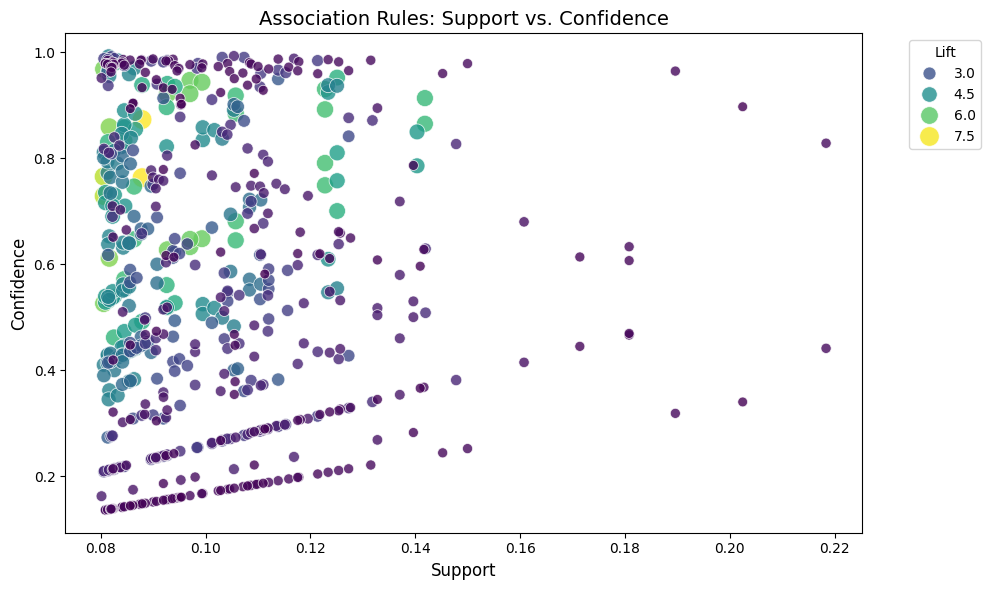

In [19]:
%run ../scripts/06_associationgraph.py ../data/04_association.csv

# Section 2: Exploratory Data Analysis
### 2.1 Distribution of Ratings
We examine the average rating distribution to establish a baseline. Initial findings suggest that romance readers are generally positive, with a rating density peaking around 4.0.

### 2.2 Engagement Volume & Correlation Analysis
We perform a Pearson correlation analysis across four key metrics: `rating`, `n_votes`, `n_comments`, and `review_length`. 
* **Key Hypothesis:** Does review length or rating sentiment drive community interaction?

### 5. Create Histogram

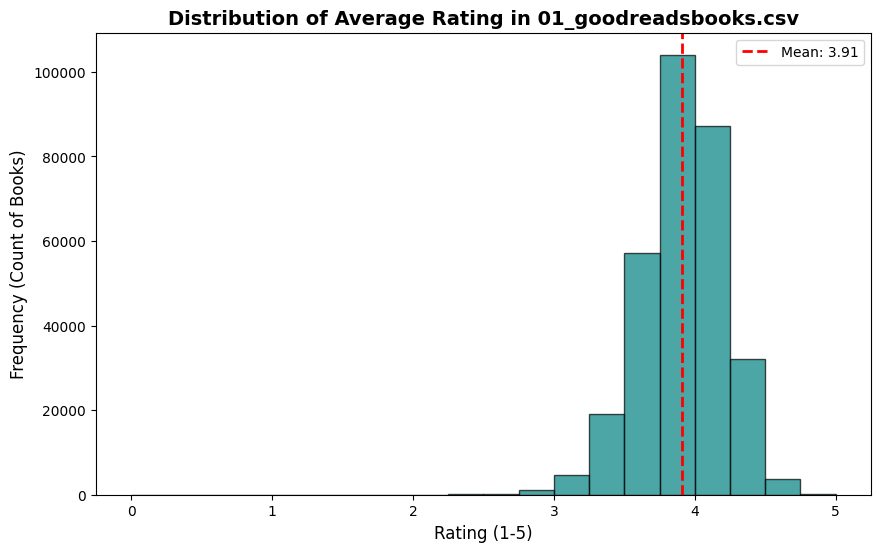

Done created ../data/02_extractedbooks.csv


In [22]:
%run ../scripts/05_histogram.py ../data/02_extractedbooks.csv ../docs/rating_histogram.png

### 6. Create Bar Geaph

reading ../data/01_filteredbooks_noadmin.json to measure tag


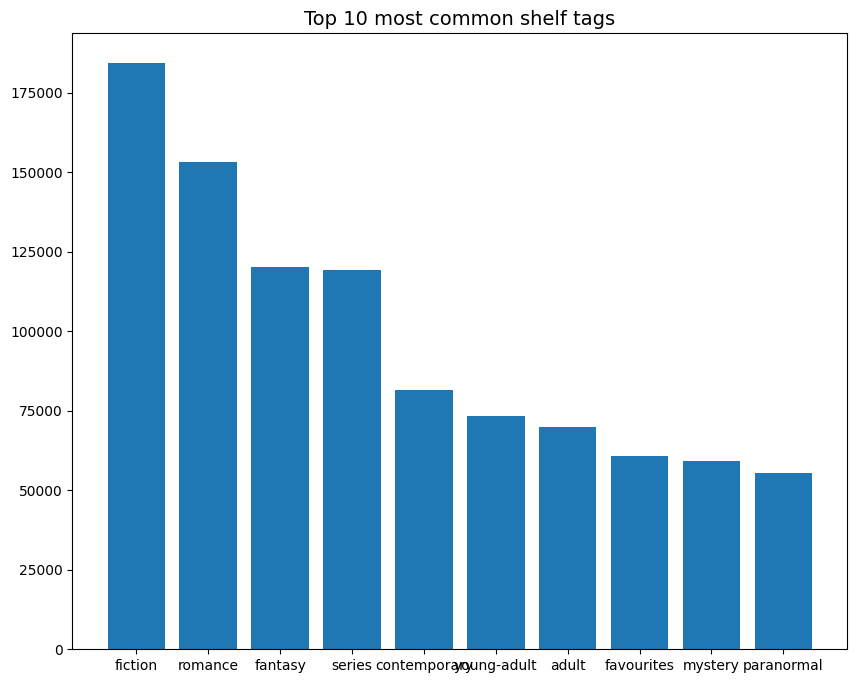


TOP 15 DISCOVERED ATTRIBUTES (SHELF TAGS)
               Tag  Book Count
           fiction      184531
           romance      153342
           fantasy      120119
            series      119359
      contemporary       81648
       young-adult       73231
             adult       69889
        favourites       60888
           mystery       59299
        paranormal       55366
historical-fiction       55333
        historical       51156
   science-fiction       50785
             i-own       50657
            sci-fi       48089
Results saved to ../data/06_tags.csv


In [25]:
%run ../scripts/05_tagfrequency.py ../data/01_filteredbooks_noadmin.json ../data/06_tags.csv ../docs/10commonbargraph.png

### 6. Generate Heatmap

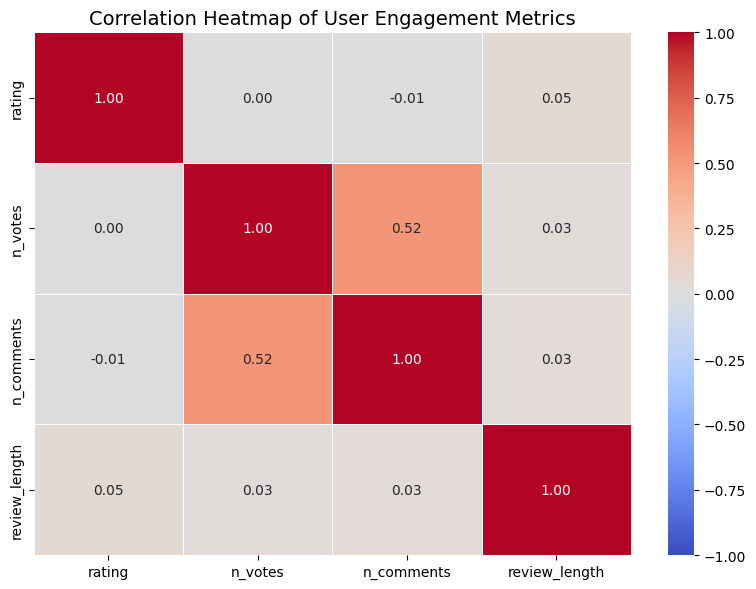

In [27]:
%run ../scripts/07_heatmap.py

### 8. Generate scatterplot

/home/david/Documents/KSU Spring 2026/Data Mining/cs4412-project/scripts/08_scatterplot.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


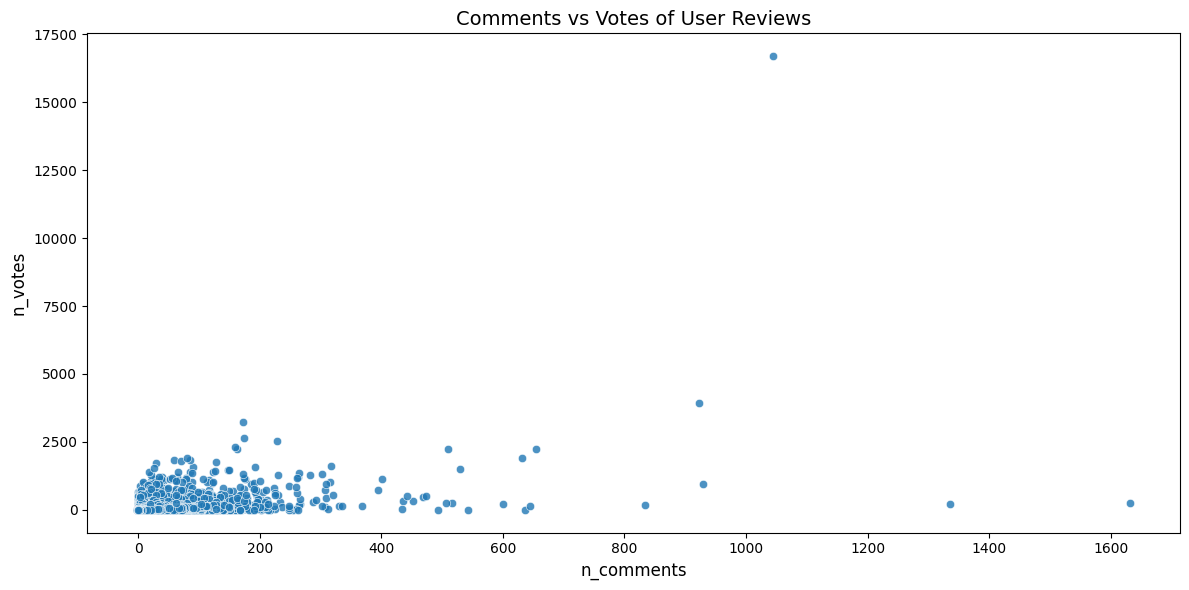

In [29]:
%run ../scripts/08_scatterplot.py

# Conclusion & Next Steps
Milestone 2 has successfully established the data pipeline and validated genre associations. 

**Upcoming Milestone 3 Plan:**
* **K-Means Clustering:** Segmenting users into "Reader Personas" based on rating variance and review frequency.
* **LDA Topic Modeling:** Extracting qualitative themes from the `review_text` to understand what drives "helpful" votes.